In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import math


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dropout, LSTM, Dense, Layer, LayerNormalization, BatchNormalization, Conv1D, MaxPooling1D, Reshape, Add
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping

import yfinance as yf



In [3]:
def scale_input(ticker, df):
    if ticker not in feature_scalers:
        print("Can Not Scale. Scaler Does Not Exist")
        return
    
    return feature_scalers[ticker].fit_transform(df)


def output_inverse_scale(ticker, value):
    if ticker not in target_scalers:
        print("Can Not Inverse. Scaler Does Not Exist")
        return

    return target_scalers[ticker].inverse_transform(np.array(value).reshape(-1, 1))


def save_model_weights(model, file_name, folder_name):
    os.makedirs(folder_name, exist_ok=True)

    words = file_name.split(".")

    model_name = words[0]

    existing_files = [f for f in os.listdir(folder_name) if f.startswith(model_name)]
    next_number = len(existing_files) + 1
    words[0] = f"{model_name}_{next_number}"

    file_name = ".".join(words)
    save_path = os.path.join(folder_name, file_name)

    model.save_weights(save_path)
    print(f"model saved to: {save_path}")


In [4]:
def plot_dataframe(df, columns = ['Open', 'Yesterday_Volume']):
    plt.figure(figsize=(15, 6)) 

    for col in columns:
        plt.plot(df.index, df[col], label=col, alpha=0.7)

    plt.title("All Columns Over Time (Scaled)")
    plt.xlabel("Time / Index")
    plt.ylabel("Scaled Value")
    
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) 
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [5]:
def apply_ssa_trend(series, window = 15, lookback = 60):
    n_total = len(series)
    result = np.zeros(n_total)
    
    result[:lookback] = series[:lookback]
    
    for t in range(lookback, n_total):
        sub_series = series[t - lookback + 1 : t + 1]
        
        N = len(sub_series)
        L = window
        K = N - L + 1
        X = np.column_stack([sub_series[i:i+L] for i in range(K)])
        
        U, Sigma, VT = np.linalg.svd(X, full_matrices=False)
        
        X1 = Sigma[0] * np.outer(U[:, 0], VT[0, :])
        
        n = N - 1
        vals = [X1[i, n-i] for i in range(max(0, n-K+1), min(n+1, L))]
        result[t] = np.mean(vals)
        
    return result

In [6]:
google_ssa, _, _ = get_dataset_columns("GOOG", "3y", 60)

NameError: name 'get_dataset_columns' is not defined

In [73]:
google_ssa.iloc[60:260]

Price,Open,Open_Trend,Vix_Trend,Trend_Diff,Target
Date,,,,,
2023-05-24,120.972670,119.100655,16.721820,1.872015,-0.196913
2023-05-25,124.277884,120.425464,16.718375,3.852420,-0.686847
2023-05-26,123.141425,121.606915,16.713136,1.534510,1.100228
2023-05-30,125.349854,122.936717,16.712870,2.413137,-1.306518
2023-05-31,122.779129,123.803552,16.769126,-1.024422,-0.266770
...,...,...,...,...,...
2024-03-05,131.751822,140.754058,14.335600,-9.002236,0.783481
2024-03-06,133.240667,139.749826,14.365747,-6.509159,-1.251496
2024-03-07,132.893274,138.681382,14.364421,-5.788108,1.008295


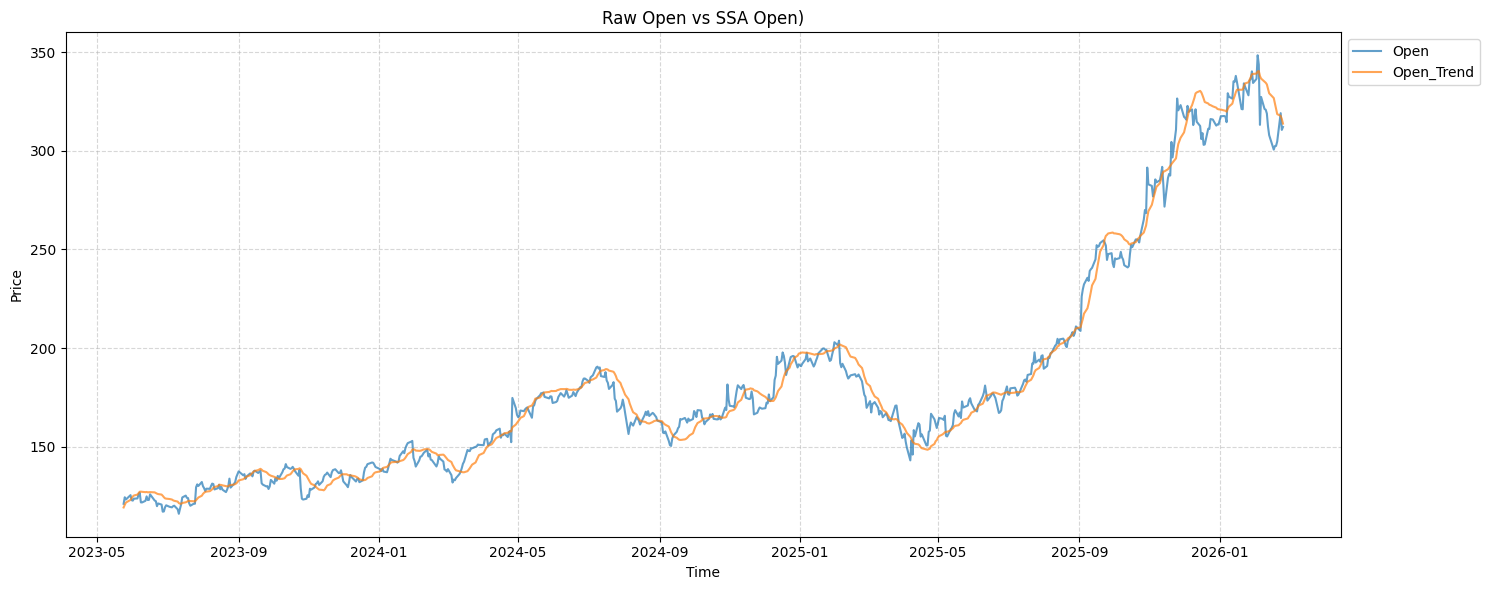

In [75]:
plt.figure(figsize=(15,6))
plt.plot(google_ssa.index[60:], google_ssa["Open"][60:], label="Open", alpha=0.7)
plt.plot(google_ssa.index[60:], google_ssa["Open_Trend"][60:], label="Open_Trend", alpha=0.7)

plt.title("Raw Open vs SSA Open)")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
def get_dataset_columns(ticker, period="1y", window=60):
    df = yf.Tickers(ticker).history(period=period)
    vix_data = yf.Tickers("^VIX").history(period=period, progress=False)

    df.columns = df.columns.droplevel(1)
    vix_data.columns = vix_data.columns.droplevel(1)

    df = df.ffill().dropna()

    vix_data = vix_data.reindex(df.index).ffill()

    df = df.drop(['Stock Splits', 'Dividends'], axis=1)

    open_trend = apply_ssa_trend(df['Open'].values, window=int((window/4)))
    vix_trend  = apply_ssa_trend(vix_data['Open'].values, window=int((window/4)))

    min_len = min(len(df), len(open_trend), len(vix_trend))

    df = df.iloc[:min_len]
    df['Open_Trend'] = open_trend[:min_len]
    df['Vix_Trend'] = vix_trend[:min_len]

    df['Trend_Diff'] = df['Open'] - df['Open_Trend']

    df['Target'] = ((df['Close'] - df['Open'])/ df['Open']) * 100 
    # df['Target'] = np.log(df['Close'] / df['Open']) * 100
    # df['Target'] = df['Close']

    df = df.drop(df.index[0])
    df = df.drop(['High', 'Low', 'Volume', 'Close'], axis=1)

    feature_cols = ["Open_Trend", "Trend_Diff", "Vix_Trend"]
    target_col = ["Target"]

    return df, feature_cols, target_col

feature_scalers = {}
target_scalers = {}

def scale_dataset(df, ticker, feature_cols, target_col, test_size=0.2, scale_target=False):
    train_size = int(len(df) * (1 - test_size))
    df_train = df.iloc[:train_size]

    if ticker not in feature_scalers:
        f_scaler = StandardScaler()
        f_scaler.fit(df_train[feature_cols])
        feature_scalers[ticker] = f_scaler

        if scale_target:
            t_scaler = StandardScaler()
            t_scaler.fit(df_train[target_col]) 
            target_scalers[ticker] = t_scaler

    df[feature_cols] = feature_scalers[ticker].transform(df[feature_cols])
    if scale_target:
        df[target_col] = target_scalers[ticker].transform(df[target_col])

    data_x = df[feature_cols].values
    data_y = df[target_col].values

    return data_x, data_y    

In [7]:
def get_full_dataset(tickers, period="1y", window_size=60, test_size=0.2):
    X_total, y_total = [], []
    
    for ticker in tickers:
        df, feature_cols, target_col = get_dataset_columns(ticker, period=period, window=window_size)
        data_x, data_y = scale_dataset(df, ticker, feature_cols, target_col, test_size, scale_target=False)
        
        for i in range(len(df) - window_size):
            X_total.append(data_x[i : i + window_size])
            y_total.append(data_y[i + window_size])

    X_data = np.array(X_total)
    y_data = np.array(y_total)

    nan_mask = np.isnan(X_data).any(axis=(1, 2))
    X_data = X_data[~nan_mask]
    y_data = y_data[~nan_mask] 

    print(f"NaN Deleted: {np.sum(nan_mask)}")
    
    test_first_index = int(len(X_data) * (1 - test_size))
    X_train, X_test = X_data[:test_first_index], X_data[test_first_index:]
    y_train, y_test = y_data[:test_first_index], y_data[test_first_index:]

    print("""
    X_train Shape : {}
    X_test Shape : {}
    y_train Shape : {}
    y_test Shape : {}
    """.format(X_train.shape, X_test.shape, y_train.shape, y_test.shape))
    
    return X_train, X_test, y_train, y_test

In [ ]:
# # Period must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
# def get_dataset(ticker, period="1y"):
#     df = yf.Tickers(ticker).history(period = period)
#     vix_data = yf.Tickers("^VIX").history(period = period, progress=False)
#     df.columns = df.columns.droplevel(1)
#     vix_data.columns = vix_data.columns.droplevel(1)
#     df = df.ffill().dropna()

#     df = df.drop(['Stock Splits', 'Dividends'], axis=1)
#     df['Open_VIX'] = vix_data['Open']
#     df['Yesterday_VIX'] = vix_data['Close'].shift(1)
#     df['Yesterday_High'] = df['High'].shift(1)
#     df['Yesterday_Low'] = df['Low'].shift(1)
#     df['Yesterday_Volume'] = df['Volume'].shift(1)
#     df['Yesterday_Close'] = df['Close'].shift(1)
#     # df['Return'] = ((df['Close'] - df['Yesterday_Close'])  * 100 / df['Yesterday_Close'])
#     df['Return'] = np.log(df['Close'] / df['Yesterday_Close']) * 100
#     # df['Return'] = df['Close']
#     df = df.drop(df.index[0])
    
#     df = df.drop(['High', 'Low', 'Volume', 'Close'], axis=1)

#     return df


# feature_scalers = {}
# target_scalers = {}

# def get_full_dataset(tickers, period="1mo", window_size=60, test_size=0.2):
#     X_total, y_total = [], []
    
#     for ticker in tickers:
#         df = get_dataset(ticker, period)
#         # feature_cols = ['Open', 'Yesterday_High', 'Yesterday_Low', 'Yesterday_Volume', 'Yesterday_Close', 'Open_VIX', 'Yesterday_VIX']
#         feature_cols = ['Open', 'Yesterday_High', 'Yesterday_Low', 'Yesterday_Volume', 'Open_VIX', 'Yesterday_VIX']
#         target_col = ['Target']

#         train_size = int(len(df) * (1 - test_size))
#         df_train = df.iloc[:train_size]

#         if ticker not in feature_scalers:
#             f_scaler = StandardScaler()
#             f_scaler.fit(df_train[feature_cols])
#             feature_scalers[ticker] = f_scaler
            
#             # t_scaler = StandardScaler()
#             # t_scaler.fit(df_train[target_col]) 
#             # target_scalers[ticker] = t_scaler

#         df[feature_cols] = feature_scalers[ticker].transform(df[feature_cols])
#         # df[target_col] = target_scalers[ticker].transform(df[target_col])

#         data_x = df[feature_cols].values
#         data_y = df[target_col].values
        
#         for i in range(len(df) - window_size):
#             X_total.append(data_x[i : i + window_size])
#             y_total.append(data_y[i + window_size])

#     X_data = np.array(X_total)
#     y_data = np.array(y_total)

#     nan_mask = np.isnan(X_data).any(axis=(1, 2))
#     X_data = X_data[~nan_mask]
#     y_data = y_data[~nan_mask] 

#     print(f"NaN Deleted: {np.sum(nan_mask)}")
    
#     test_first_index = int(len(X_data) * (1 - test_size))
#     X_train, X_test = X_data[:test_first_index], X_data[test_first_index:]
#     y_train, y_test = y_data[:test_first_index], y_data[test_first_index:]

#     print("""
#     X_train Shape : {}
#     X_test Shape : {}
#     y_train Shape : {}
#     y_test Shape : {}
#     """.format(X_train.shape, X_test.shape, y_train.shape, y_test.shape))
    
#     return X_train, X_test, y_train, y_test

In [8]:
tickers_5 = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]
tickers_20 = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", 
    "TSM", "AVGO", "ASML",
    "JPM", "BAC", "V", "MA",
    "JNJ", "LLY", "UNH", "PG", "KO", "PEP"
]
tickers_50 = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "TSLA", "NFLX", "ADBE", "CRM", "ORCL",
    "NVDA", "TSM", "AVGO", "ASML", "AMD", "INTC", "QCOM", "TXN", "MU", "AMAT",
    "JPM", "BAC", "V", "MA", "GS", "MS", "AXP", "PYPL", "WFC", "BLK",
    "JNJ", "LLY", "UNH", "PFE", "ABBV", "MRK", "TMO", "DHR", "AMGN", "ISRG",
    "PG", "KO", "PEP", "WMT", "COST", "NKE", "MCD", "HD", "DIS", "SBUX"
]

window_size = 40
feature_num = 3

X_train, X_test, y_train, y_test = get_full_dataset(
    tickers_50,
    period = "3y",
    window_size = window_size, 
    test_size = 0.2
)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

NaN Deleted: 0

    X_train Shape : (28480, 40, 3)
    X_test Shape : (7120, 40, 3)
    y_train Shape : (28480, 1)
    y_test Shape : (7120, 1)
    


In [23]:
pd.DataFrame(pd.DataFrame(y_test).describe())

,0
count,7110.000000
mean,0.033809
std,1.181477
min,-9.358516
25%,-0.619848
50%,0.034764
75%,0.667035
max,12.486162


In [ ]:
def get_LSTM_model(window_size=60, feature_num=3):
    dropout_rate = 0.2
    input_layer = Input(shape = (window_size, feature_num), name="Input")
    batch_norm_layer = BatchNormalization(name="BatchNormalization_1")(input_layer)
    LSTM_layer = LSTM(64, return_sequences=True, name = "LSTM_1")(batch_norm_layer)
    hidden_layer = Dropout(dropout_rate, name = f"Dropout_1_{dropout_rate}")(LSTM_layer)
    hidden_layer = BatchNormalization(name="BatchNormalization_2")(hidden_layer)
    hidden_layer = LSTM(32, name = "LSTM_2")(hidden_layer)
    hidden_layer = Dropout(dropout_rate, name = f"Dropout_2_{dropout_rate}")(hidden_layer)
    hidden_layer = Dense(16, activation = "relu", name="Dense")(hidden_layer)
    output_layer = Dense(1, activation = "linear", name="Output")(hidden_layer)

    model = Model(inputs = input_layer, outputs = output_layer, name='LSTM_BatchNorm_Dropout0.2_3y_window30')

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    # loss_fn = tf.keras.losses.Huber()
    model.compile(optimizer = optimizer, loss = 'mse', metrics=['mae', tf.keras.metrics.RootMeanSquaredError()])
    return model

LSTM_model = get_LSTM_model(window_size, feature_num)
LSTM_model.summary()

Model: "LSTM_BatchNorm_Dropout0.2_3y_window30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 40, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization_1            │ (None, 40, 3)          │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_1 (LSTM)                   │ (None, 40, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1_0.2 (Dropout)         │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization_2            │ (None, 40, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2_0.2 (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,637 (119.68 KB)

 Trainable params: 30,503 (119.15 KB)

 Non-trainable params: 134 (536.00 B)

In [10]:
def get_CNN_LSTM_hybrid(window_size=60, feature_num=7):
    dropout_rate = 0.2
    
    input_layer = Input(shape=(window_size, feature_num), name="Input")
    
    x = Conv1D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu', name="Conv1D_1")(input_layer)
    x = LayerNormalization(name="LayerNormalization_1")(x)
    x = Conv1D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu', name="Conv1D_2")(x)
    x = LayerNormalization(name="LayerNormalization_2")(x)
    
    x = MaxPooling1D(pool_size=2, name="Max_Pooling")(x)
    
    x = LSTM(64, return_sequences=True, name="LSTM_1")(x)
    x = Dropout(dropout_rate, name="Dropout_1")(x)
    x = BatchNormalization(name="BatchNormalization_1")(x)
    
    x = LSTM(32, return_sequences=False, name="LSTM_2")(x)
    x = Dropout(dropout_rate, name="Dropout_2")(x)
    x = BatchNormalization(name="BatchNormalization_2")(x)
    
    x = Dense(16, activation="relu", name="FullyConnected_1")(x)
    output_layer = Dense(1, activation="linear", name="Output")(x)

    model = Model(inputs=input_layer, outputs=output_layer, name='SSA_CNN_LSTM_Hybrid')

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, 
                  loss='mse', 
                  metrics=['mae', tf.keras.metrics.RootMeanSquaredError()])
    return model

CNN_LSTM_model = get_CNN_LSTM_hybrid(window_size, feature_num)
CNN_LSTM_model.summary()

Model: "SSA_CNN_LSTM_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 40, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_1 (Conv1D)               │ (None, 40, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LayerNormalization_1            │ (None, 40, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_2 (Conv1D)               │ (None, 40, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LayerNormalization_2            │ (None, 40, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pooling (MaxPooling1D)      │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_1 (LSTM)                   │ (None, 20, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization_1            │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization_2            │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FullyConnected_1 (Dense)        │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,617 (232.88 KB)

 Trainable params: 59,425 (232.13 KB)

 Non-trainable params: 192 (768.00 B)

In [1]:
def get_CNN_Diffusion_LSTM_hybrid(window_size=60, feature_num=7):
    dropout_rate = 0.2
    
    input_layer = Input(shape=(window_size, feature_num), name="Input")
    t_input = Input(shape=(1,), name="Time_Step")
    
    x = Conv1D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu', name="Conv1D_1")(input_layer)
    x = LayerNormalization(name="LayerNormalization_1")(x)
    x = Conv1D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu', name="Conv1D_2")(x)
    cnn_features = LayerNormalization(name="LayerNormalization_2")(x)

    t_emb = Dense(64, activation='swish', name="Time_Emb")(t_input)
    t_emb = Reshape((1, 64), name="Time_Emb_Reshape")(t_emb)

    d = Add(name="Merge_Layer")([cnn_features, t_emb])
    d = Conv1D(64, 3, padding='same', activation='swish', name="Conv1D_3")(d)

    latent_bottleneck = Add(name="Bottleneck")([d, cnn_features])

    x = MaxPooling1D(pool_size=2, name="MaxPool_Layer")(latent_bottleneck)
    x = LSTM(64, return_sequences=True, name="LSTM_1")(x)
    x = Dropout(dropout_rate, name="Dropout")(x)
    
    x = LSTM(32, return_sequences=False, name="LSTM_2")(x)
    x = Dense(16, activation="relu", name="Dense")(x)
    output_layer = Dense(1, activation="linear", name="Output")(x)

    model = Model(inputs=[input_layer, t_input], outputs=output_layer, name='SSA_CNN_DIFFUSION_LSTM')

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, 
                  loss='mse', 
                  metrics=['mae', tf.keras.metrics.RootMeanSquaredError()])
    return model

CNN_Diffusion_LSTM_model = get_CNN_Diffusion_LSTM_hybrid(window_size, feature_num)
CNN_Diffusion_LSTM_model.summary()

NameError: name 'window_size' is not defined

In [11]:
earlyStopping_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
)

In [12]:
CNN_LSTM_model.fit(
    X_train, 
    y_train, 
    epochs = 50, 
    batch_size = 32,
    validation_data = (X_test, y_test),
    callbacks = [earlyStopping_callback]
)

Epoch 1/50
890/890 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 3.0372 - mae: 1.2252 - root_mean_squared_error: 1.7428 - val_loss: 1.4336 - val_mae: 0.8683 - val_root_mean_squared_error: 1.1973
Epoch 2/50
890/890 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 2.9812 - mae: 1.2070 - root_mean_squared_error: 1.7266 - val_loss: 1.4392 - val_mae: 0.8701 - val_root_mean_squared_error: 1.1997
Epoch 3/50
890/890 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 2.9699 - mae: 1.2035 - root_mean_squared_error: 1.7233 - val_loss: 1.4085 - val_mae: 0.8588 - val_root_mean_squared_error: 1.1868
Epoch 4/50
890/890 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 2.9627 - mae: 1.2020 - root_mean_squared_error: 1.7213 - val_loss: 1.3963 - val_mae: 0.8549 - val_root_mean_squared_error: 1.1817
Epoch 5/50
890/890 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 2.9455 - mae: 1.2004 - root_mean_squared_error: 1.7163 - val_loss: 1.3869 - val_mae: 0.8550 - val_root_mean_squared_error: 1.1777
Epoch 6/50
890/890 ━━━━━━━━━━━━━━━━━━━━ 8s 9

In [13]:
LSTM_model.fit(
    X_train, 
    y_train, 
    epochs = 50, 
    batch_size = 32,
    validation_data = (X_test, y_test),
    callbacks = [earlyStopping_callback]
)

Epoch 1/50
890/890 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 2.9672 - mae: 1.2042 - root_mean_squared_error: 1.7226 - val_loss: 1.4089 - val_mae: 0.8589 - val_root_mean_squared_error: 1.1870
Epoch 2/50
890/890 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 2.9579 - mae: 1.2011 - root_mean_squared_error: 1.7199 - val_loss: 1.4054 - val_mae: 0.8570 - val_root_mean_squared_error: 1.1855
Epoch 3/50
890/890 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 2.9512 - mae: 1.1988 - root_mean_squared_error: 1.7179 - val_loss: 1.4024 - val_mae: 0.8567 - val_root_mean_squared_error: 1.1842
Epoch 4/50
890/890 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 2.9462 - mae: 1.1979 - root_mean_squared_error: 1.7165 - val_loss: 1.4020 - val_mae: 0.8564 - val_root_mean_squared_error: 1.1841
Epoch 5/50
890/890 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 2.9498 - mae: 1.1989 - root_mean_squared_error: 1.7175 - val_loss: 1.4045 - val_mae: 0.8568 - val_root_mean_squared_error: 1.1851


In [29]:
# save_model_weights(LSTM_model, "LSTM_TEST.weights.h5", "models")

In [30]:
# def interpret_mae_to_percentage(mae_value):
#     log_error = mae_value / 100
#     price_ratio = 10**log_error
#     percentage_error = (price_ratio - 1) * 100
#     return percentage_error

In [14]:
loss, mae, rmse = CNN_LSTM_model.evaluate(X_test, y_test)

print(f"loss: {loss}")
print(f"mae: {mae}")
print(f"rmse: {rmse}")

print("----------------")

loss, mae, rmse = LSTM_model.evaluate(X_test, y_test)

print(f"loss: {loss}")
print(f"mae: {mae}")
print(f"rmse: {rmse}")

223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3847 - mae: 0.8569 - root_mean_squared_error: 1.1767
loss: 1.3846906423568726
mae: 0.8568938374519348
rmse: 1.1767288446426392
----------------
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4089 - mae: 0.8589 - root_mean_squared_error: 1.1870
loss: 1.4088515043258667
mae: 0.8589475750923157
rmse: 1.1869505643844604


In [32]:
# loss, mae, rmse = LSTM_model.evaluate(X_test, y_test)

# print(f"loss: {loss}")
# print(f"mae: {mae}")
# print(f"rmse: {rmse}")

In [33]:
# def predict_and_plot(ticker, period="1mo"):
#     df = get_dataset(ticker, period)
#     feature_cols = ['Open', 'Yesterday_High', 'Yesterday_Low', 'Yesterday_Volume', 'Open_VIX', 'Yesterday_VIX']
#     target_col = ['Return']

#     train_size = int(len(df) * (1 - test_size))
#     df_train = df.iloc[:train_size]

#     if ticker not in feature_scalers:
#             f_scaler = StandardScaler()
#             f_scaler.fit(df_train[feature_cols])
#             feature_scalers[ticker] = f_scaler
            
#             t_scaler = StandardScaler()
#             t_scaler.fit(df_train[target_col]) 
#             target_scalers[ticker] = t_scaler
    

In [ ]:
def make_3class_label(y, threshold=0.05):
    labels = np.zeros_like(y, dtype=int)

    labels[y > threshold] = 2
    labels[(y > 0) & (y <= threshold)] = 1 
    labels[y <= 0] = 0
    
    return labels

223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
                 0
count  7120.000000
mean      0.023774
std       0.291408
min      -0.276189
25%      -0.036847
50%       0.006841
75%       0.036921
max       6.523692
Test set class distribution:
Class 0: 3175 samples
Class 1: 592 samples
Class 2: 3353 samples

Prediction set class distribution:
Class 0: 271 samples
Class 1: 6308 samples
Class 2: 541 samples


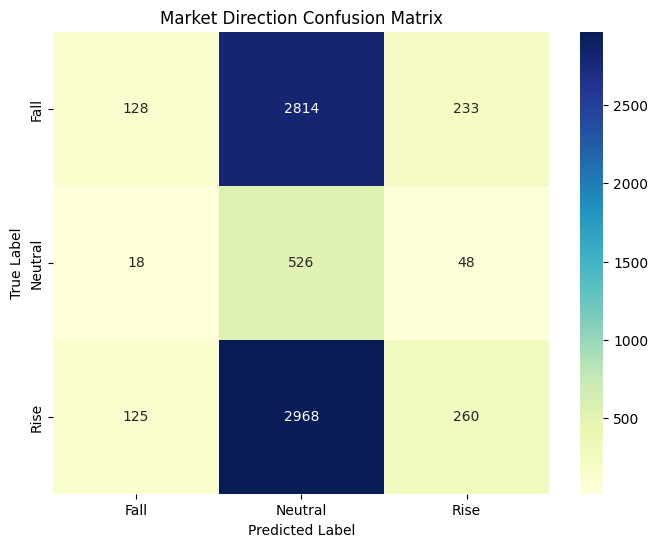


Classification Report:
              precision    recall  f1-score   support

        Fall       0.47      0.04      0.07      3175
     Neutral       0.08      0.89      0.15       592
        Rise       0.48      0.08      0.13      3353

    accuracy                           0.13      7120
   macro avg       0.35      0.34      0.12      7120
weighted avg       0.44      0.13      0.11      7120



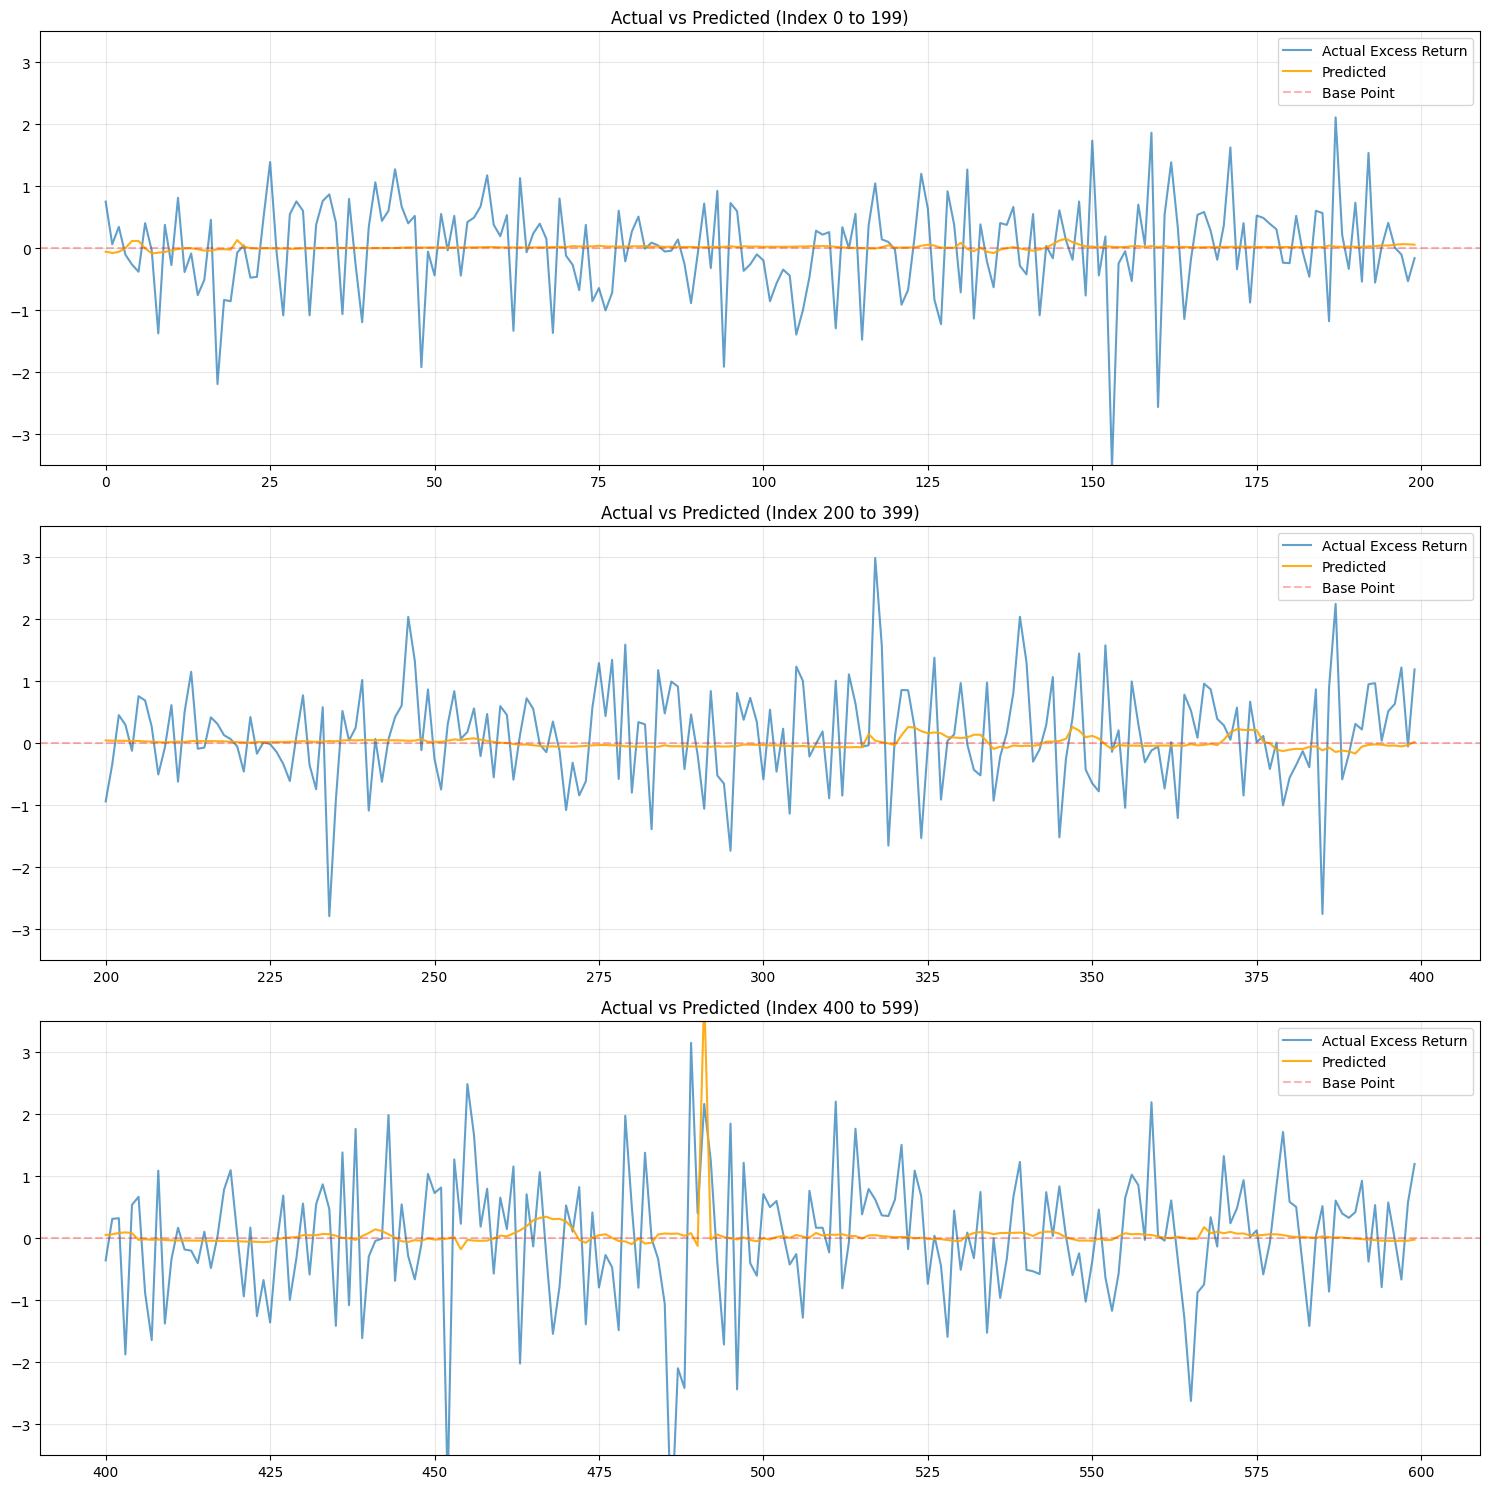

In [29]:
predictions = CNN_LSTM_model.predict(X_test)

print(pd.DataFrame(predictions).describe())

# base_point = pd.DataFrame(predictions).mean().item()
base_point = 0
class_names = ['Fall', 'Neutral', 'Rise']
threshold = 0.1

y_test_class = make_3class_label(y_test, threshold)
predictions_class = make_3class_label(predictions, threshold)

unique, counts = np.unique(y_test_class, return_counts=True)
print("Test set class distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

unique, counts = np.unique(predictions_class, return_counts=True)
print("\nPrediction set class distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_class, predictions_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Market Direction Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_class, predictions_class, target_names=class_names))

y_test_flat = y_test.flatten()
preds_flat = predictions.flatten()

comparison_df = pd.DataFrame({
    'Actual': y_test_flat,
    'Predicted': preds_flat
})

chunk_size = 200
y_min_limit = -3.5 
y_max_limit = 3.5 

total_len = len(comparison_df)
# num_plots = int(np.ceil(total_len / chunk_size))
num_plots = 3

fig, axes = plt.subplots(num_plots, 1, figsize=(15, 5 * num_plots), sharex=False)

if num_plots == 1:
    axes = [axes]

for i in range(num_plots):
    start = i * chunk_size
    end = min((i + 1) * chunk_size, total_len)
    
    subset = comparison_df.iloc[start:end]
    
    axes[i].plot(subset.index, subset['Actual'], label='Actual Excess Return', alpha=0.7)
    axes[i].plot(subset.index, subset['Predicted'], label='Predicted', alpha=0.9, color='orange')
    
    axes[i].set_ylim(y_min_limit, y_max_limit) 
    
    axes[i].axhline(base_point, label='Base Point', color='red', linestyle='--', alpha=0.3)
    axes[i].set_title(f'Actual vs Predicted (Index {start} to {end-1})')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
predictions = LSTM_model.predict(X_test)

print(pd.DataFrame(predictions).describe())

# base_point = pd.DataFrame(predictions).mean().item()
base_point = 0

y_test_sign = (y_test > base_point).astype(int)
pred_sign = (predictions > base_point).astype(int)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_sign, pred_sign)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn', center=0,
            xticklabels=['Fall (0)', 'Rise (1)'], 
            yticklabels=['Fall (0)', 'Rise (1)'])

plt.title('Market Direction Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_sign, pred_sign, target_names=['Fall', 'Rise']))

y_test_flat = y_test.flatten()
preds_flat = predictions.flatten()

comparison_df = pd.DataFrame({
    'Actual': y_test_flat,
    'Predicted': preds_flat
})

chunk_size = 200
y_min_limit = -3.5 
y_max_limit = 3.5 

total_len = len(comparison_df)
num_plots = int(np.ceil(total_len / chunk_size))

fig, axes = plt.subplots(num_plots, 1, figsize=(15, 5 * num_plots), sharex=False)

if num_plots == 1:
    axes = [axes]

for i in range(num_plots):
    start = i * chunk_size
    end = min((i + 1) * chunk_size, total_len)
    
    subset = comparison_df.iloc[start:end]
    
    axes[i].plot(subset.index, subset['Actual'], label='Actual Excess Return', alpha=0.7)
    axes[i].plot(subset.index, subset['Predicted'], label='Predicted', alpha=0.9, color='orange')
    
    axes[i].set_ylim(y_min_limit, y_max_limit) 
    
    axes[i].axhline(base_point, label='Base Point', color='red', linestyle='--', alpha=0.3)
    axes[i].set_title(f'Actual vs Predicted (Index {start} to {end-1})')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
# predictions = LSTM_model.predict(X_test)

# y_test_sign = (y_test > 0).astype(int)
# pred_sign = (predictions > 0).astype(int)

# plt.figure(figsize=(8, 6))
# cm = confusion_matrix(y_test_sign, pred_sign)
# sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', center=0,
#             xticklabels=['Fall (0)', 'Rise (1)'], 
#             yticklabels=['Fall (0)', 'Rise (1)'])

# plt.title('Market Direction Confusion Matrix')
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.show()

# print("\nClassification Report:")
# print(classification_report(y_test_final, pred_sign_final, target_names=['Fall', 'Rise']))

In [37]:
pd.DataFrame(predictions).describe()

,0
count,7110.000000
mean,0.049221
std,0.135533
min,-0.380783
25%,-0.040043
50%,0.046111
75%,0.125862
max,0.552841


y_test_flat = y_test.flatten()
preds_flat = predictions.flatten()

comparison_df = pd.DataFrame({
    'Actual': y_test_flat,
    'Predicted': preds_flat
})

comparison_df['Correct_Direction'] = (
    (comparison_df['Actual'] > 0) == (comparison_df['Predicted'] > 0)
)

# print(comparison_df.head(50))

plt.figure(figsize=(15, 6))
plt.plot(comparison_df['Actual'][0:200], label='Actual Excess Return', alpha=0.7)
plt.plot(comparison_df['Predicted'][0:200], label='Predicted', alpha=0.9)

# x = range(100)
# actual = comparison_df['Actual'][:100]
# predicted = comparison_df['Predicted'][:100]

# plt.vlines(x, actual, predicted, color='red', alpha=0.4, label='Error (Difference)')

plt.title('Actual vs Predicted (First 200)')
# plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.legend()
plt.show()